In [1]:
import sys

print(sys.version)
print(sys.executable)

3.12.11 (main, Aug 27 2026, 10:16:07) [Clang 21.0.0 (clang-2100.1.1.101)]
/Users/yemei/Documents/Dev/autoformation/projects/traffic-prediction-paris/.venv/bin/python


In [1]:
import httpx
import pandas as pd
import pyarrow
import duckdb

print(f"httpx:   {httpx.__version__}")
print(f"pandas:  {pd.__version__}")
print(f"pyarrow: {pyarrow.__version__}")
print(f"duckdb:  {duckdb.__version__}")

httpx:   0.28.1
pandas:  2.3.3
pyarrow: 21.0.0
duckdb:  1.5.5


In [2]:
import shared
import traffic_prediction

print(shared.__file__)
print(traffic_prediction.__file__)

/Users/yemei/Documents/Dev/autoformation/projects/traffic-prediction-paris/packages/shared/shared/__init__.py
/Users/yemei/Documents/Dev/autoformation/projects/traffic-prediction-paris/packages/traffic_prediction/traffic_prediction/__init__.py


# Traffic Prediction Paris — Data Exploration

## 1. Paris Traffic Data

Exploration du dataset `comptages-routiers-permanents`
via Paris Open Data Explore API v2.1.

In [3]:
import httpx
import pandas as pd

In [4]:
BASE_URL = "https://opendata.paris.fr"

DATASET = "comptages-routiers-permanents"

TRAFFIC_API_URL = (
    f"{BASE_URL}/api/explore/v2.1/catalog/"
    f"datasets/{DATASET}/records"
)

params = {
    "limit": 5,
}

response = httpx.get(
    TRAFFIC_API_URL,
    params=params,
    timeout=30.0,
)

response.raise_for_status()
data = response.json()

results = data["results"]

df = pd.DataFrame(results)

df

,iu_ac,libelle,t_1h,q,k,etat_trafic,iu_nd_amont,libelle_nd_amont,iu_nd_aval,libelle_nd_aval,etat_barre,date_debut,date_fin,geo_point_2d,geo_shape
0,4830,Claude_Bernard,2025-07-23T16:00:00+00:00,None,None,Inconnu,2560,Monge-Claude_Bernard,2574,Claude_Bernard-Arbalete,Invalide,1996-10-17,2023-01-01,"{'lon': 2.348887445320026, 'lat': 48.839199441...","{'type': 'Feature', 'geometry': {'coordinates'..."
1,4831,Claude_Bernard,2025-07-23T18:00:00+00:00,None,None,Inconnu,2574,Claude_Bernard-Arbalete,2575,Claude_Bernard-Berthollet,Invalide,1996-10-17,2023-01-01,"{'lon': 2.3466213302123013, 'lat': 48.84006930...","{'type': 'Feature', 'geometry': {'coordinates'..."
2,4831,Claude_Bernard,2025-07-23T16:00:00+00:00,None,None,Inconnu,2574,Claude_Bernard-Arbalete,2575,Claude_Bernard-Berthollet,Invalide,1996-10-17,2023-01-01,"{'lon': 2.3466213302123013, 'lat': 48.84006930...","{'type': 'Feature', 'geometry': {'coordinates'..."
3,4831,Claude_Bernard,2025-07-23T15:00:00+00:00,None,None,Inconnu,2574,Claude_Bernard-Arbalete,2575,Claude_Bernard-Berthollet,Invalide,1996-10-17,2023-01-01,"{'lon': 2.3466213302123013, 'lat': 48.84006930...","{'type': 'Feature', 'geometry': {'coordinates'..."
4,4831,Claude_Bernard,2025-07-23T14:00:00+00:00,None,None,Inconnu,2574,Claude_Bernard-Arbalete,2575,Claude_Bernard-Berthollet,Invalide,1996-10-17,2023-01-01,"{'lon': 2.3466213302123013, 'lat': 48.84006930...","{'type': 'Feature', 'geometry': {'coordinates'..."


In [14]:
print(df.shape)
print("\n")
print(df.columns.tolist())
print("\n")
print(df.info())

(5, 15)


['iu_ac', 'libelle', 't_1h', 'q', 'k', 'etat_trafic', 'iu_nd_amont', 'libelle_nd_amont', 'iu_nd_aval', 'libelle_nd_aval', 'etat_barre', 'date_debut', 'date_fin', 'geo_point_2d', 'geo_shape']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   iu_ac             5 non-null      object
 1   libelle           5 non-null      object
 2   t_1h              5 non-null      object
 3   q                 0 non-null      object
 4   k                 0 non-null      object
 5   etat_trafic       5 non-null      object
 6   iu_nd_amont       5 non-null      object
 7   libelle_nd_amont  5 non-null      object
 8   iu_nd_aval        5 non-null      object
 9   libelle_nd_aval   5 non-null      object
 10  etat_barre        5 non-null      object
 11  date_debut        5 non-null      object
 12  date_fin          5 non-null      object
 13  g

In [15]:
data.keys()
results[0]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   iu_ac             5 non-null      object
 1   libelle           5 non-null      object
 2   t_1h              5 non-null      object
 3   q                 0 non-null      object
 4   k                 0 non-null      object
 5   etat_trafic       5 non-null      object
 6   iu_nd_amont       5 non-null      object
 7   libelle_nd_amont  5 non-null      object
 8   iu_nd_aval        5 non-null      object
 9   libelle_nd_aval   5 non-null      object
 10  etat_barre        5 non-null      object
 11  date_debut        5 non-null      object
 12  date_fin          5 non-null      object
 13  geo_point_2d      5 non-null      object
 14  geo_shape         5 non-null      object
dtypes: object(15)
memory usage: 732.0+ bytes


In [16]:
df[
    [
        "iu_ac",
        "libelle",
        "t_1h",
        "q",
        "k",
        "etat_trafic",
        "etat_barre",
    ]
]

,iu_ac,libelle,t_1h,q,k,etat_trafic,etat_barre
0,4830,Claude_Bernard,2025-07-23T16:00:00+00:00,None,None,Inconnu,Invalide
1,4831,Claude_Bernard,2025-07-23T18:00:00+00:00,None,None,Inconnu,Invalide
2,4831,Claude_Bernard,2025-07-23T16:00:00+00:00,None,None,Inconnu,Invalide
3,4831,Claude_Bernard,2025-07-23T15:00:00+00:00,None,None,Inconnu,Invalide
4,4831,Claude_Bernard,2025-07-23T14:00:00+00:00,None,None,Inconnu,Invalide


In [11]:
params = {
    "where": "q is not null and k is not null",
    "limit": 5,
}

response = httpx.get(
    TRAFFIC_API_URL,
    params=params,
    timeout=30.0,
)

response.raise_for_status()

data_valid = response.json()

In [12]:
data_valid.keys()

dict_keys(['total_count', 'results'])

In [13]:
data_valid["total_count"]

12584748

In [14]:
df_valid = pd.DataFrame(data_valid["results"])

df_valid[
    [
        "iu_ac",
        "libelle",
        "t_1h",
        "q",
        "k",
        "etat_trafic",
        "etat_barre",
    ]
]

,iu_ac,libelle,t_1h,q,k,etat_trafic,etat_barre
0,4836,Av_Daumesnil,2025-07-23T21:00:00+00:00,132.0,1.15000,Fluide,Ouvert
1,4836,Av_Daumesnil,2025-07-23T20:00:00+00:00,166.0,1.41000,Fluide,Ouvert
2,4836,Av_Daumesnil,2025-07-23T19:00:00+00:00,164.0,1.41889,Fluide,Ouvert
3,4836,Av_Daumesnil,2025-07-23T15:00:00+00:00,185.0,1.88611,Fluide,Ouvert
4,4837,Av_Daumesnil,2025-07-23T21:00:00+00:00,132.0,1.00611,Fluide,Ouvert


In [15]:
df_valid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   iu_ac             5 non-null      object 
 1   libelle           5 non-null      object 
 2   t_1h              5 non-null      object 
 3   q                 5 non-null      float64
 4   k                 5 non-null      float64
 5   etat_trafic       5 non-null      object 
 6   iu_nd_amont       5 non-null      object 
 7   libelle_nd_amont  5 non-null      object 
 8   iu_nd_aval        5 non-null      object 
 9   libelle_nd_aval   5 non-null      object 
 10  etat_barre        5 non-null      object 
 11  date_debut        5 non-null      object 
 12  date_fin          5 non-null      object 
 13  geo_point_2d      5 non-null      object 
 14  geo_shape         5 non-null      object 
dtypes: float64(2), object(13)
memory usage: 732.0+ bytes


In [16]:
data_valid["results"][0]

{'iu_ac': '4836',
 'libelle': 'Av_Daumesnil',
 't_1h': '2025-07-23T21:00:00+00:00',
 'q': 132.0,
 'k': 1.15,
 'etat_trafic': 'Fluide',
 'iu_nd_amont': '2572',
 'libelle_nd_amont': 'Av_Daumesnil-Dugommier',
 'iu_nd_aval': '3045',
 'libelle_nd_aval': 'Pl_Felix_Eboue_Ouest',
 'etat_barre': 'Ouvert',
 'date_debut': '1996-10-17',
 'date_fin': '2023-01-01',
 'geo_point_2d': {'lon': 2.39387813531224, 'lat': 48.83995789461699},
 'geo_shape': {'type': 'Feature',
  'geometry': {'coordinates': [[2.3927256866092756, 48.84021798270368],
    [2.3950305840152044, 48.839697806530296]],
   'type': 'LineString'},
  'properties': {}}}

## 2. Exploration temporelle d'un tronçon

Analyse du tronçon `iu_ac = 4836` — Avenue Daumesnil.

In [17]:
road_id = "4836"

params = {
    "where": (
        f'iu_ac = "{road_id}" '
        "and q is not null "
        "and k is not null"
    ),
    "order_by": "t_1h desc",
    "limit": 100,
}

response = httpx.get(
    TRAFFIC_API_URL,
    params=params,
    timeout=30.0,
)

response.raise_for_status()

road_data = response.json()

In [20]:
df_road = pd.DataFrame(road_data["results"])

df_road[
    [
        "t_1h",
        "q",
        "k",
        "etat_trafic",
        "etat_barre",
    ]
].head(20)

,t_1h,q,k,etat_trafic,etat_barre
0,2026-08-26T22:00:00+00:00,174.0,2.39389,Fluide,Ouvert
1,2026-08-26T21:00:00+00:00,171.0,1.64889,Fluide,Ouvert
2,2026-08-26T20:00:00+00:00,168.0,1.97445,Fluide,Ouvert
3,2026-08-26T19:00:00+00:00,164.0,1.81833,Fluide,Ouvert
4,2026-08-26T18:00:00+00:00,212.0,3.12556,Fluide,Ouvert
5,2026-08-26T17:00:00+00:00,220.0,2.31445,Fluide,Ouvert
6,2026-08-26T16:00:00+00:00,259.0,31.75000,Saturé,Ouvert
7,2026-08-26T15:00:00+00:00,287.0,21.13834,Pré-saturé,Ouvert
8,2026-08-26T14:00:00+00:00,177.0,1.99556,Fluide,Ouvert
9,2026-08-26T13:00:00+00:00,204.0,5.64667,Fluide,Ouvert


In [18]:
road_data["total_count"]

9600

In [36]:
df_road["timestamp_utc"] = pd.to_datetime(
    df_road["t_1h"],
    utc=True,
)

df_road = df_road.sort_values("timestamp_utc")

df_road["time_diff"] = df_road["timestamp_utc"].diff()

In [37]:
df_road["time_diff"].value_counts().sort_index()

time_diff
0 days 01:00:00    98
0 days 02:00:00     1
Name: count, dtype: int64

In [38]:
df_road["timestamp_utc"] = pd.to_datetime(
    df_road["t_1h"],
    utc=True,
)
df_road["timestamp_paris"] = (
    df_road["timestamp_utc"]
    .dt.tz_convert("Europe/Paris")
)
df_road[
    [
        "t_1h",
        "timestamp_utc",
        "timestamp_paris",
        "q",
        "k",
    ]
].head()

,t_1h,timestamp_utc,timestamp_paris,q,k
99,2026-08-22T18:00:00+00:00,2026-08-22 18:00:00+00:00,2026-08-22 20:00:00+02:00,155.0,1.93389
98,2026-08-22T19:00:00+00:00,2026-08-22 19:00:00+00:00,2026-08-22 21:00:00+02:00,136.0,1.62500
97,2026-08-22T20:00:00+00:00,2026-08-22 20:00:00+00:00,2026-08-22 22:00:00+02:00,138.0,1.57722
96,2026-08-22T21:00:00+00:00,2026-08-22 21:00:00+00:00,2026-08-22 23:00:00+02:00,186.0,2.34056
95,2026-08-22T22:00:00+00:00,2026-08-22 22:00:00+00:00,2026-08-23 00:00:00+02:00,125.0,1.43500


In [27]:
df_road.loc[
    df_road["time_diff"] > pd.Timedelta(hours=1),
    ["timestamp_utc", "timestamp_paris", "q", "k", "time_diff"]
]

/var/folders/hl/1zfww0m11s925x_8cyp413km0000gp/T/ipykernel_90766/3351119650.py:2: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  df_road["time_diff"] > pd.Timedelta(hours=1),


,timestamp_utc,timestamp_paris,q,k,time_diff
86,2026-08-23 08:00:00+00:00,2026-08-23 10:00:00+02:00,120.0,1.42944,0 days 02:00:00


In [28]:
gap_index = df_road.index[
    df_road["time_diff"] > pd.Timedelta(hours=1)
][0]

gap_position = df_road.index.get_loc(gap_index)

df_road.iloc[
    max(0, gap_position - 2): gap_position + 3
][
    ["timestamp_utc", "timestamp_paris", "q", "k", "etat_trafic"]
]

/var/folders/hl/1zfww0m11s925x_8cyp413km0000gp/T/ipykernel_90766/2377581508.py:2: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  df_road["time_diff"] > pd.Timedelta(hours=1)


,timestamp_utc,timestamp_paris,q,k,etat_trafic
88,2026-08-23 05:00:00+00:00,2026-08-23 07:00:00+02:00,36.0,0.54278,Fluide
87,2026-08-23 06:00:00+00:00,2026-08-23 08:00:00+02:00,77.0,1.01167,Fluide
86,2026-08-23 08:00:00+00:00,2026-08-23 10:00:00+02:00,120.0,1.42944,Fluide
85,2026-08-23 09:00:00+00:00,2026-08-23 11:00:00+02:00,117.0,1.35834,Fluide
84,2026-08-23 10:00:00+00:00,2026-08-23 12:00:00+02:00,124.0,1.47945,Fluide


In [29]:
params = {
    "where": f'iu_ac = "{road_id}"',
    "order_by": "t_1h desc",
    "limit": 100,
}

response = httpx.get(
    TRAFFIC_API_URL,
    params=params,
    timeout=30.0,
)

response.raise_for_status()

road_data_all = response.json()

df_road_all = pd.DataFrame(road_data_all["results"])

In [30]:
df_road_all[
    [
        "t_1h",
        "q",
        "k",
        "etat_trafic",
        "etat_barre",
    ]
].head(20)

,t_1h,q,k,etat_trafic,etat_barre
0,2026-08-26T22:00:00+00:00,174.0,2.39389,Fluide,Ouvert
1,2026-08-26T21:00:00+00:00,171.0,1.64889,Fluide,Ouvert
2,2026-08-26T20:00:00+00:00,168.0,1.97445,Fluide,Ouvert
3,2026-08-26T19:00:00+00:00,164.0,1.81833,Fluide,Ouvert
4,2026-08-26T18:00:00+00:00,212.0,3.12556,Fluide,Ouvert
5,2026-08-26T17:00:00+00:00,220.0,2.31445,Fluide,Ouvert
6,2026-08-26T16:00:00+00:00,259.0,31.75000,Saturé,Ouvert
7,2026-08-26T15:00:00+00:00,287.0,21.13834,Pré-saturé,Ouvert
8,2026-08-26T14:00:00+00:00,177.0,1.99556,Fluide,Ouvert
9,2026-08-26T13:00:00+00:00,204.0,5.64667,Fluide,Ouvert


In [31]:
df_road_all[["q", "k"]].isna().sum()

q    1
k    1
dtype: int64

In [32]:
df_road_all.loc[
    df_road_all["q"].isna() | df_road_all["k"].isna(),
    ["t_1h", "q", "k", "etat_trafic", "etat_barre"]
]

,t_1h,q,k,etat_trafic,etat_barre
87,2026-08-23T07:00:00+00:00,NaN,NaN,Inconnu,Invalide


### Observation — valeurs manquantes

Certaines observations existent bien dans la série temporelle mais possèdent
des valeurs `q` et `k` manquantes.

Exemple observé pour `iu_ac = 4836` :

- `t_1h = 2026-08-23T07:00:00+00:00`
- `q = NaN`
- `k = NaN`
- `etat_trafic = Inconnu`
- `etat_barre = Invalide`

Il ne faut donc pas supprimer les valeurs manquantes lors de l'ingestion brute.
Elles doivent être conservées afin de distinguer une mesure invalide d'un
véritable timestamp absent.

In [33]:
# Test de contuinité
df_road_all["timestamp_utc"] = pd.to_datetime(
    df_road_all["t_1h"],
    utc=True,
)

df_road_all = df_road_all.sort_values("timestamp_utc")

df_road_all["time_diff"] = (
    df_road_all["timestamp_utc"].diff()
)

df_road_all["time_diff"].value_counts().sort_index()

time_diff
0 days 01:00:00    99
Name: count, dtype: int64

In [40]:
df_road_all["timestamp_paris"] = (
    df_road_all["timestamp_utc"]
    .dt.tz_convert("Europe/Paris")
)

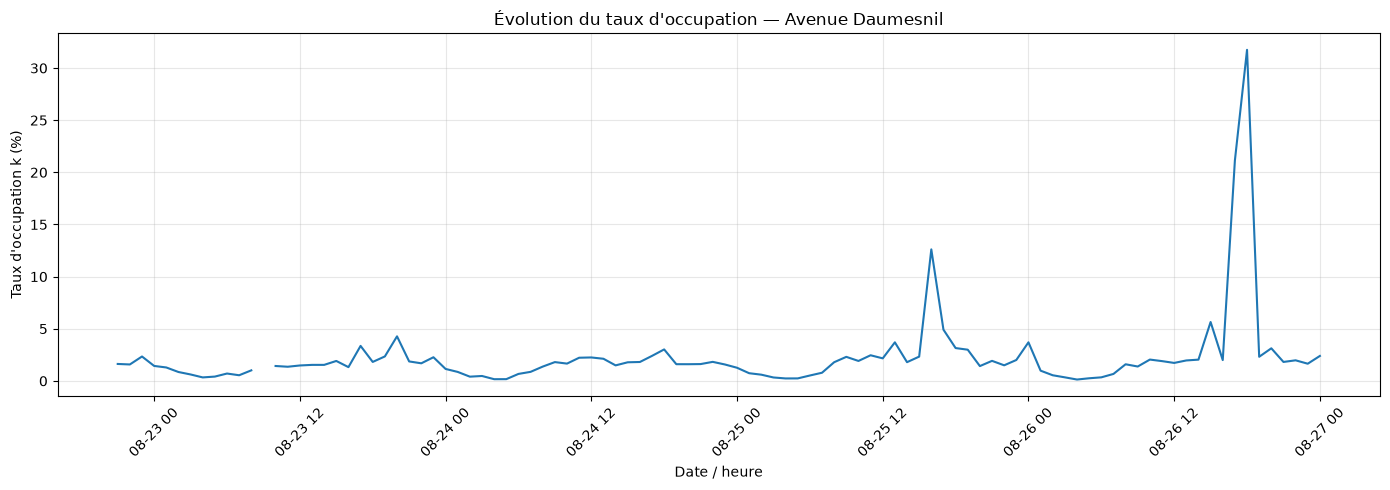

In [41]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_road_all["timestamp_paris"],
    df_road_all["k"],
)

ax.set_title("Évolution du taux d'occupation — Avenue Daumesnil")
ax.set_xlabel("Date / heure")
ax.set_ylabel("Taux d'occupation k (%)")

ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

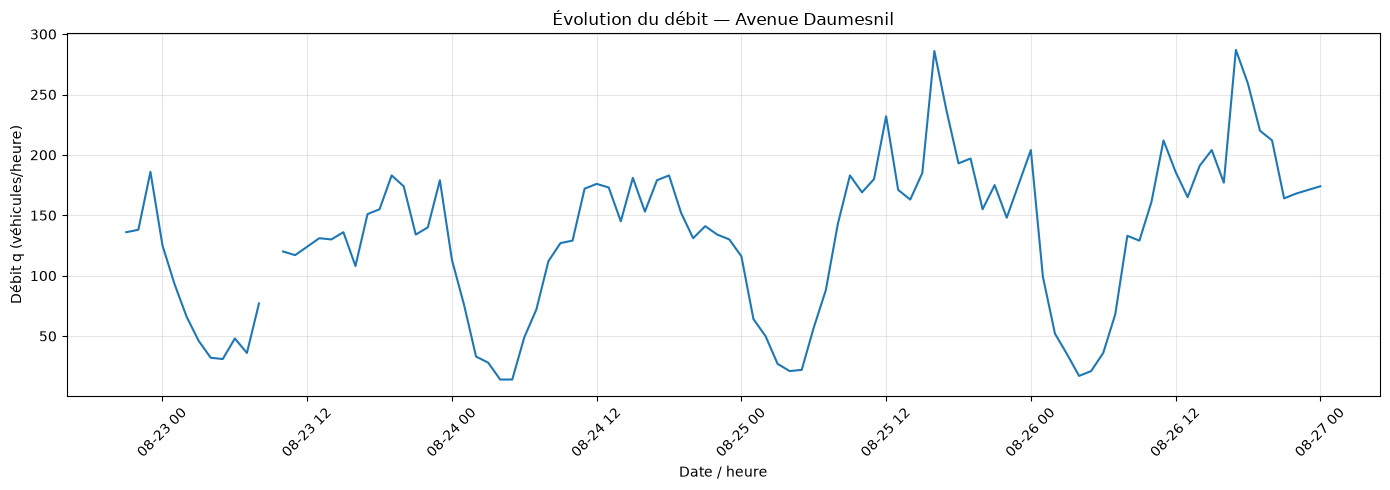

In [42]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_road_all["timestamp_paris"],
    df_road_all["q"],
)

ax.set_title("Évolution du débit — Avenue Daumesnil")
ax.set_xlabel("Date / heure")
ax.set_ylabel("Débit q (véhicules/heure)")

ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 1. Le débit q présente un cycle journalier très net

Sur le deuxième graphique, on distingue clairement un motif qui se répète :

forte baisse pendant la nuit ;
minimum en début de matinée ;
remontée rapide ;
trafic beaucoup plus important pendant la journée ;
nouvelle baisse la nuit suivante.

Par exemple, autour des 24, 25 et 26 août, on retrouve une forme assez similaire.

## 2. k raconte une histoire différente

Le premier graphique est encore plus intéressant.

La plupart du temps : k ≈ 0–5 %
Donc le capteur est relativement peu occupé et, selon les seuils documentés par Paris, le trafic reste dans la catégorie Fluide tant que k < 15.

Mais nous voyons deux événements remarquables :
25 août → k ≈ 12–13 %
26 août → k ≈ 32 %

    Le deuxième pic dépasse le seuil de 30 %. Il pourrait donc correspondre à une situation Saturée, si la valeur et l'état associé sont cohérents.

Et regarde quelque chose d'intéressant : au moment du gros pic de k du 26 août, q est également élevé, autour de 280–290 véhicules/h.

In [43]:
df_road_all.loc[
    df_road_all["k"] >= 15,
    [
        "timestamp_paris",
        "q",
        "k",
        "etat_trafic",
        "etat_barre",
    ],
].sort_values("timestamp_paris")

,timestamp_paris,q,k,etat_trafic,etat_barre
7,2026-08-26 17:00:00+02:00,287.0,21.13834,Pré-saturé,Ouvert
6,2026-08-26 18:00:00+02:00,259.0,31.75000,Saturé,Ouvert


### Relation entre débit et congestion

L'analyse du tronçon `iu_ac = 4836` montre que le débit `q` seul
ne suffit pas à caractériser la congestion.

Le 26 août 2026 :

| Heure | q | k | État |
|---|---:|---:|---|
| 17:00 | 287 | 21.14 % | Pré-saturé |
| 18:00 | 259 | 31.75 % | Saturé |

Entre 17 h et 18 h, le débit diminue alors que le taux
d'occupation augmente fortement et que le trafic passe de
`Pré-saturé` à `Saturé`.

Le taux d'occupation `k` constitue donc une variable centrale
pour représenter le niveau de congestion.

## 4. Analyse globale des tronçons

Après l'étude détaillée d'un tronçon, nous analysons maintenant
la couverture du réseau afin d'identifier les tronçons exploitables
pour la modélisation.

In [45]:
params = {
    "select": "iu_ac, count(*) as n_observations",
    "group_by": "iu_ac",
    "order_by": "n_observations desc",
    "limit": 100,
}

response = httpx.get(
    TRAFFIC_API_URL,
    params=params,
    timeout=30.0,
)

response.raise_for_status()

road_stats = response.json()

In [46]:
road_stats.keys()

dict_keys(['total_count', 'results'])

In [47]:
road_stats["total_count"]

100

In [48]:
df_road_stats = pd.DataFrame(road_stats["results"])

df_road_stats.head(10)

,iu_ac,n_observations
0,1586,9734
1,4225,9734
2,4596,9734
3,5758,9734
4,782,9734
5,1,9733
6,10,9733
7,100,9733
8,1001,9733
9,1006,9733


In [49]:
df_road_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   iu_ac           100 non-null    object
 1   n_observations  100 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 1.7+ KB


In [50]:
params = {
    "select": "iu_ac, count(*) as n_observations",
    "group_by": "iu_ac",
    "order_by": "n_observations desc",
    "limit": 100,
    "offset": 100,
}

response = httpx.get(
    TRAFFIC_API_URL,
    params=params,
    timeout=30.0,
)

response.raise_for_status()

road_stats_page_2 = response.json()

df_road_stats_page_2 = pd.DataFrame(
    road_stats_page_2["results"]
)

df_road_stats_page_2.head()

,iu_ac,n_observations
0,1142,9733
1,1143,9733
2,1144,9733
3,1146,9733
4,1148,9733


In [51]:
len(df_road_stats_page_2)

100

In [52]:
set(df_road_stats["iu_ac"]) & set(df_road_stats_page_2["iu_ac"])

set()

In [53]:
def fetch_road_stats(page_size: int = 100) -> pd.DataFrame:
    rows = []
    offset = 0

    while True:
        params = {
            "select": "iu_ac, count(*) as n_observations",
            "group_by": "iu_ac",
            "order_by": "n_observations desc",
            "limit": page_size,
            "offset": offset,
        }

        response = httpx.get(
            TRAFFIC_API_URL,
            params=params,
            timeout=30.0,
        )
        response.raise_for_status()

        page = response.json()["results"]

        if not page:
            break

        rows.extend(page)

        if len(page) < page_size:
            break

        offset += page_size

    return pd.DataFrame(rows)

In [54]:
df_road_stats_all = fetch_road_stats()

In [55]:
df_road_stats_all.shape

(2989, 2)

In [56]:
df_road_stats_all.head()

,iu_ac,n_observations
0,1586,9734
1,4225,9734
2,4596,9734
3,5758,9734
4,782,9734


In [57]:
df_road_stats_all.tail()

,iu_ac,n_observations
2984,ERREUR a la ligne 1 :,1
2985,ID de processus : 13690,1
2986,"ID de session : 82, Numero de serie : 401",1
2987,ORA-03113: end-of-file on communication channel,1
2988,WITH df AS (,1


In [59]:
df_road_stats_all["iu_ac"].nunique()

2989

In [60]:
df_road_stats_all["n_observations"].describe()

count    2989.000000
mean     9698.703580
std       548.523057
min         1.000000
25%      9733.000000
50%      9733.000000
75%      9733.000000
max      9734.000000
Name: n_observations, dtype: float64

In [61]:
thresholds = [1, 24, 168, 1000, 5000, 9000, 9700]

for threshold in thresholds:
    count = (
        df_road_stats_all["n_observations"] < threshold
    ).sum()

    print(f"< {threshold:4d} observations : {count}")

<    1 observations : 0
<   24 observations : 6
<  168 observations : 6
< 1000 observations : 6
< 5000 observations : 11
< 9000 observations : 14
< 9700 observations : 14


In [62]:
df_road_stats_all.nsmallest(
    20,
    "n_observations",
)

,iu_ac,n_observations
2983,*,1
2984,ERREUR a la ligne 1 :,1
2985,ID de processus : 13690,1
2986,"ID de session : 82, Numero de serie : 401",1
2987,ORA-03113: end-of-file on communication channel,1
2988,WITH df AS (,1
2981,4880,1116
2982,5847,1116
2980,7291,1353
2979,233,2221


In [63]:
max_observations = df_road_stats_all["n_observations"].max()

df_road_stats_all["coverage_ratio"] = (
    df_road_stats_all["n_observations"]
    / max_observations
)

df_road_stats_all["coverage_ratio"].describe()

count    2989.000000
mean        0.996374
std         0.056351
min         0.000103
25%         0.999897
50%         0.999897
75%         0.999897
max         1.000000
Name: coverage_ratio, dtype: float64

### Qualité de la clé `iu_ac`

L'analyse des valeurs distinctes de `iu_ac` a identifié 2 989 valeurs.

Six valeurs ne correspondent manifestement pas à des identifiants de
tronçons routiers et semblent provenir d'une erreur technique Oracle
présente dans les données sources (`ORA-03113`, `ID de processus`, etc.).

Les données brutes ne doivent pas être modifiées lors de l'ingestion,
mais une étape de validation devra contrôler les `iu_ac`.

Une validation syntaxique peut identifier les valeurs non numériques,
mais la validation définitive devra être réalisée en comparant `iu_ac`
avec le dataset de référence `referentiel-comptages-routiers`.

In [4]:
import pandas as pd
vedir_df = pd.read_parquet("../data/processed/ml_dataset_4836.parquet")
vedir_df

,iu_ac,timestamp_utc,q,k,hour,day_of_week,is_weekend,q_lag_1h,k_lag_1h,q_lag_2h,k_lag_2h,q_lag_24h,k_lag_24h,target_k_1h
0,4836,2025-07-01 03:00:00+00:00,33.0,0.42056,5,1,False,NaN,NaN,NaN,NaN,NaN,NaN,0.62722
1,4836,2025-07-01 04:00:00+00:00,54.0,0.62722,6,1,False,33.0,0.42056,NaN,NaN,NaN,NaN,1.11500
2,4836,2025-07-01 05:00:00+00:00,95.0,1.11500,7,1,False,54.0,0.62722,33.0,0.42056,NaN,NaN,1.55278
3,4836,2025-07-01 06:00:00+00:00,134.0,1.55278,8,1,False,95.0,1.11500,54.0,0.62722,NaN,NaN,2.48889
4,4836,2025-07-01 07:00:00+00:00,222.0,2.48889,9,1,False,134.0,1.55278,95.0,1.11500,NaN,NaN,2.93889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,4836,2025-08-23 13:00:00+00:00,92.0,0.54667,15,5,True,80.0,0.44389,107.0,1.10278,152.0,1.30500,0.75444
980,4836,2025-08-23 14:00:00+00:00,107.0,0.75444,16,5,True,92.0,0.54667,80.0,0.44389,169.0,1.67444,0.75667
981,4836,2025-08-23 15:00:00+00:00,100.0,0.75667,17,5,True,107.0,0.75444,92.0,0.54667,182.0,1.61055,0.77278
982,4836,2025-08-23 16:00:00+00:00,115.0,0.77278,18,5,True,100.0,0.75667,107.0,0.75444,148.0,3.14778,1.31834
